23BCE20135


YELCHURI.HARSHITHA


L26+27

**MISSILE OR DRONE -> INTERCEPTOR MISSILE**

*Input:Speed,Altitude*    
*Output:Interceptor missile*

For this project,no particular dataset is available on internet.So,I took reference from multiple websites and created a database to train this decision tree model.

---
References:
1.Missile Specs Dataset:
https://www.kaggle.com/datasets/teasloth/missiles


---
2.Ukraine Attacks Dataset:
https://www.kaggle.com/datasets/piterfm/massive-missile-attacks-on-ukraine

---
3.Iran-Israel War OSINT Dataset:

https://github.com/danielrosehill/Iran-Israel-War-2026-Data

---
4.North Korea Missile Tests Dataset:

https://github.com/nagix/nk-missile-tests

---
5.Allies Missile Defense Intercept Test Record:

https://www.missiledefenseadvocacy.org/missile-defense-systems-2/missile-defense-intercept-test-record/allies-missile-defense-intercept-test-record

---
And different web resources are analysed.






These files contain missile specifications, drone threats, and interceptor systems.

For example some missile specifications include systems like Emad and Ghadr MRBMs with their ranges and characteristics.

Interceptor systems include Arrow-3, Arrow-2, David’s Sling and Iron Dome, each designed for different interception altitudes and ranges.

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import json
import random

Load CSV Datasets

In [2]:
interceptors = pd.read_csv("interceptor_systems.csv")
drones = pd.read_csv("drone_threats.csv")
threats = pd.read_csv("threat_systems.csv")
intercept_tests = pd.read_csv("intercept_tests.csv")
hypersonic = pd.read_csv("hypersonic_missiles_military - Sheet1.csv")

print(interceptors.head())
print(drones.head())
print(threats.head())

  Interceptor       System_Type  Speed_kmh  Range_km  Max_Altitude_m  \
0   Iron Dome   Short-range SAM       2595        70           10000   
1      NASAMS  Medium-range SAM       4140        40           21000   
2  IRIS-T SLM  Short-medium SAM       3000        40           20000   
3       Akash        Medium SAM       3600        45           18000   
4    Aster-30    Long-range SAM       5040       120           20000   

          Intercept_Method  
0  Proximity fragmentation  
1  Proximity fragmentation  
2  Proximity fragmentation  
3  Proximity fragmentation  
4            Fragmentation  
        Threat_Name   Threat_Class  Speed_kmh  Range_km  Altitude_m  RCS_m2  \
0        Shahed-136  Loitering UAV        185      2500        4000    0.01   
1     Bayraktar TB2       MALE UAV        222       150        7620    0.10   
2       MQ-9 Reaper       MALE UAV        482      1850       15240    0.30   
3  RQ-4 Global Hawk       HALE UAV        575     22000       18288    0.10  

Load JSON Datasets

In [3]:
with open("iranian_weapons.json") as f:
    iranian_weapons = json.load(f)

with open("defense_systems.json") as f:
    defense_systems = json.load(f)

with open("waves.json") as f:
    waves = json.load(f)

print("JSON datasets loaded")

JSON datasets loaded


Load War Wave Datasets

In [4]:
wave_files = [
    "tp1-waves.json",
    "tp-2waves.json",
    "tp3-waves.json",
    "tp4-waves.json"
]

wave_data = []

for f in wave_files:
    with open(f) as file:
        data = json.load(file)
        wave_data.append(data)

print("Wave datasets loaded")

Wave datasets loaded


Extracting Real Interceptor Usage

In [5]:
interceptor_records = []

for data in wave_data:
    for wave in data["waves"]:
        systems = wave.get("interception", {}).get("interception_systems", [])

        for sys in systems:
            interceptor_records.append(sys)

interceptor_usage = pd.DataFrame(interceptor_records, columns=["Interceptor"])

print(interceptor_usage.head())

        Interceptor
0         Iron Dome
1     David's Sling
2     Patriot PAC-3
3  Aegis BMD / SM-3
4           Arrow-2


Computing Historical Success Rates

In [6]:
success_rates = interceptor_usage["Interceptor"].value_counts(normalize=True)

print(success_rates)

interceptor_prob = success_rates.to_dict()

Interceptor
Arrow-2             0.256410
Arrow-3             0.239316
THAAD               0.188034
Iron Dome           0.179487
David's Sling       0.034188
Patriot             0.034188
Aegis BMD / SM-3    0.025641
Patriot PAC-3       0.017094
TRUE                0.017094
SM-3                0.008547
Name: proportion, dtype: float64


Drone Dataset

In [7]:
drone_data = drones[['Threat_Name','Threat_Class','Speed_kmh','Range_km','Altitude_m','Payload_kg']]

drone_data = drone_data.rename(columns={
'Threat_Name':'Threat',
'Threat_Class':'Class',
'Speed_kmh':'Speed',
'Range_km':'Range',
'Altitude_m':'Altitude',
'Payload_kg':'Payload'
})

Rocket Dataset

In [8]:
rocket_data = threats[['Threat_Name','Threat_Class','Range_km','Payload']]

rocket_data = rocket_data.rename(columns={
'Threat_Name':'Threat',
'Threat_Class':'Class',
'Range_km':'Range'
})

rocket_data['Speed'] = rocket_data['Range'] * 60
rocket_data['Altitude'] = rocket_data['Range'] * 500

rocket_data = rocket_data[['Threat','Class','Speed','Range','Altitude','Payload']]

Hypersonic Dataset

In [9]:
hypersonic_data = hypersonic.rename(columns={
'Model Name':'Threat',
'Attack Type':'Class',
'Maximum Speed':'Speed',
'Range (km)':'Range'
})

hypersonic_data = hypersonic_data[['Threat','Class','Speed','Range']]

hypersonic_data['Speed'] = hypersonic_data['Speed'].astype(str).str.extract('(\d+)').astype(float)

hypersonic_data['Speed'] = hypersonic_data['Speed'] * 1225
hypersonic_data['Altitude'] = hypersonic_data['Range'] * 80
hypersonic_data['Payload'] = 500

<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1522/3357533917.py:10: SyntaxWarning: invalid escape sequence '\d'
  hypersonic_data['Speed'] = hypersonic_data['Speed'].astype(str).str.extract('(\d+)').astype(float)


Combine Threat Datasets

In [10]:
combined_threats = pd.concat(
    [drone_data, rocket_data, hypersonic_data],
    ignore_index=True
)

print(combined_threats.head())

             Threat          Class  Speed    Range  Altitude Payload
0        Shahed-136  Loitering UAV  185.0   2500.0    4000.0    50.0
1     Bayraktar TB2       MALE UAV  222.0    150.0    7620.0   150.0
2       MQ-9 Reaper       MALE UAV  482.0   1850.0   15240.0  1700.0
3  RQ-4 Global Hawk       HALE UAV  575.0  22000.0   18288.0  1360.0
4     Wing Loong II       MALE UAV  370.0   4000.0    9000.0   480.0


Interceptor Capability Filter

In [11]:
def get_candidate_interceptors(row):

    altitude = row["Altitude"]
    speed = row["Speed"]

    candidates = []

    if altitude < 10000:
        candidates += ["Iron Dome"]

    if altitude < 20000:
        candidates += ["NASAMS","David's Sling"]

    if altitude < 60000:
        candidates += ["Arrow-2","Aster-30"]

    if altitude >= 60000:
        candidates += ["Arrow-3","THAAD"]

    return candidates

In [12]:
def assign_interceptor(row):

    candidates = get_candidate_interceptors(row)

    weights = []

    for c in candidates:
        weights.append(interceptor_prob.get(c,0.05))

    if sum(weights)==0:
        weights=[1]*len(candidates)

    return random.choices(candidates,weights=weights)[0]

Dataset constructed from multiple missile and interceptor
data sources and integrated into a unified dataset.      


In [14]:
combined_threats['Payload'] = combined_threats['Payload'].astype(str).str.extract('(\d+)')
combined_threats['Payload'] = combined_threats['Payload'].astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1522/3921879540.py:1: SyntaxWarning: invalid escape sequence '\d'
  combined_threats['Payload'] = combined_threats['Payload'].astype(str).str.extract('(\d+)')


In [15]:
df = combined_threats.copy()

df["Interceptor"] = df.apply(assign_interceptor, axis=1)

print(df.head())

             Threat          Class  Speed    Range  Altitude  Payload  \
0        Shahed-136  Loitering UAV  185.0   2500.0    4000.0     50.0   
1     Bayraktar TB2       MALE UAV  222.0    150.0    7620.0    150.0   
2       MQ-9 Reaper       MALE UAV  482.0   1850.0   15240.0   1700.0   
3  RQ-4 Global Hawk       HALE UAV  575.0  22000.0   18288.0   1360.0   
4     Wing Loong II       MALE UAV  370.0   4000.0    9000.0    480.0   

  Interceptor  
0     Arrow-2  
1   Iron Dome  
2     Arrow-2  
3     Arrow-2  
4     Arrow-2  


In [16]:
numeric_cols = ['Range','Speed','Altitude','Payload']

augmented_rows=[]

target_rows=3000

while len(df)+len(augmented_rows)<target_rows:

    row=df.sample(1).iloc[0].copy()

    for col in numeric_cols:
        noise=np.random.uniform(-0.12,0.12)
        row[col]=row[col]*(1+noise)

    augmented_rows.append(row)

augmented_df=pd.DataFrame(augmented_rows)

final_dataset=pd.concat([df,augmented_df],ignore_index=True)

print(final_dataset.shape)

(3000, 7)


In [17]:
final_dataset.to_csv(
"missile_interceptor_dataset_3000.csv",
index=False
)

**ENCODING**

In [41]:
from sklearn.preprocessing import LabelEncoder

le_class=LabelEncoder()
le_interceptor=LabelEncoder()
le_threat=LabelEncoder()

final_dataset["Class"]=le_class.fit_transform(final_dataset["Class"])
final_dataset["Interceptor"]=le_interceptor.fit_transform(final_dataset["Interceptor"])
final_dataset["Threat"]=le_threat.fit_transform(final_dataset["Threat"])

Train Test Split

In [42]:
X=final_dataset[['Class','Speed','Range','Altitude','Payload']]
y=final_dataset['Interceptor']


In [43]:
from sklearn.model_selection import train_test_split

splits = [0.15,0.20,0.30,0.40]

split_results = []

for split in splits:

    X_train,X_test,y_train,y_test = train_test_split(
        X,y,test_size=split,random_state=101
    )

    print("Test Size:",split)
    print("Train:",X_train.shape,"Test:",X_test.shape)

Test Size: 0.15
Train: (2550, 5) Test: (450, 5)
Test Size: 0.2
Train: (2400, 5) Test: (600, 5)
Test Size: 0.3
Train: (2100, 5) Test: (900, 5)
Test Size: 0.4
Train: (1800, 5) Test: (1200, 5)


In [44]:
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(
criterion="entropy",
max_depth=6,
min_samples_leaf=2,
random_state=101
)

model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=6, min_samples_leaf=2,
                       random_state=101)

In [45]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

results = []

splits = [0.15,0.20,0.30,0.40]

for split in splits:

    X_train,X_test,y_train,y_test = train_test_split(
        X,y,test_size=split,random_state=101
    )

    for depth in [4,6,8]:

        for leaf in [1,2,3]:

            model = DecisionTreeClassifier(
                criterion="entropy",
                max_depth=depth,
                min_samples_leaf=leaf,
                random_state=101
            )

            model.fit(X_train,y_train)

            pred = model.predict(X_test)

            acc = accuracy_score(y_test,pred)

            results.append([split,depth,leaf,acc])

results_df = pd.DataFrame(
    results,
    columns=["test_split","max_depth","min_leaf","accuracy"]
)

results_df

,test_split,max_depth,min_leaf,accuracy
0,0.15,4,1,0.788889
1,0.15,4,2,0.788889
2,0.15,4,3,0.788889
3,0.15,6,1,0.862222
4,0.15,6,2,0.862222
5,0.15,6,3,0.862222
6,0.15,8,1,0.884444
7,0.15,8,2,0.882222
8,0.15,8,3,0.882222
9,0.20,4,1,0.780000


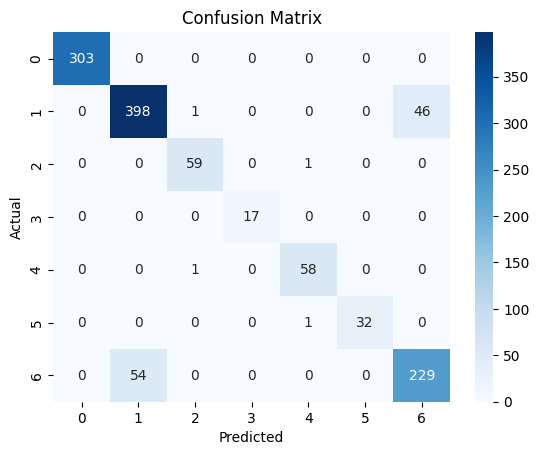

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [47]:
import numpy as np

cm = confusion_matrix(y_test, pred)

FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)

specificity = TN / (TN + FP)
fpr = FP / (FP + TN)
fnr = FN / (FN + TP)

print("Average Specificity:", specificity.mean())
print("Average FPR:", fpr.mean())
print("Average FNR:", fnr.mean())

Average Specificity: 0.9821151442810558
Average FPR: 0.0178848557189441
Average FNR: 0.051478506841173756


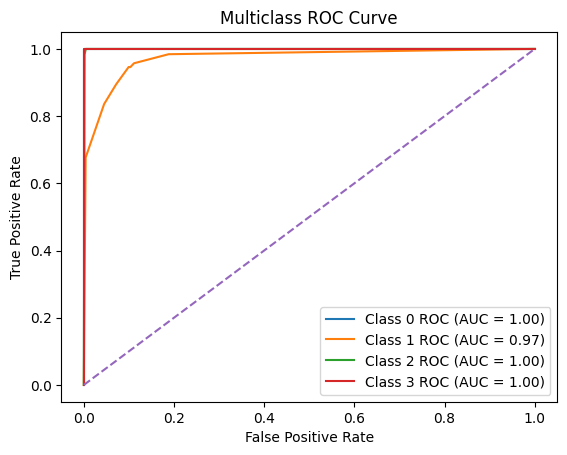

In [48]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

y_bin = label_binarize(y_test, classes=[0,1,2,3])
prob = model.predict_proba(X_test)

n_classes = y_bin.shape[1]

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(y_bin[:,i], prob[:,i])
    roc_auc = auc(fpr,tpr)

    plt.plot(fpr,tpr,label=f"Class {i} ROC (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Multiclass ROC Curve")

plt.legend()
plt.show()

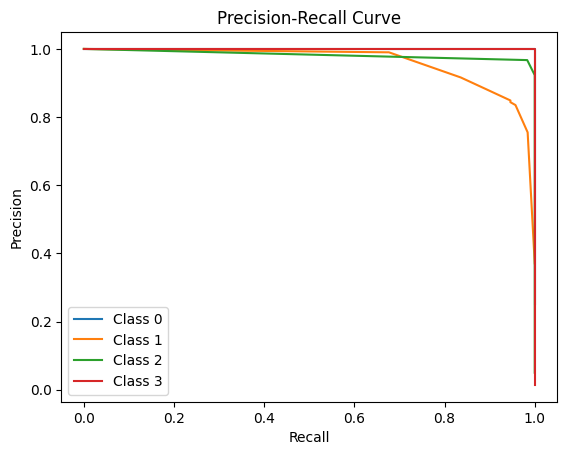

In [49]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

n_classes = y_bin.shape[1]

for i in range(n_classes):

    precision, recall, _ = precision_recall_curve(y_bin[:,i], prob[:,i])

    plt.plot(recall, precision, label=f"Class {i}")

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

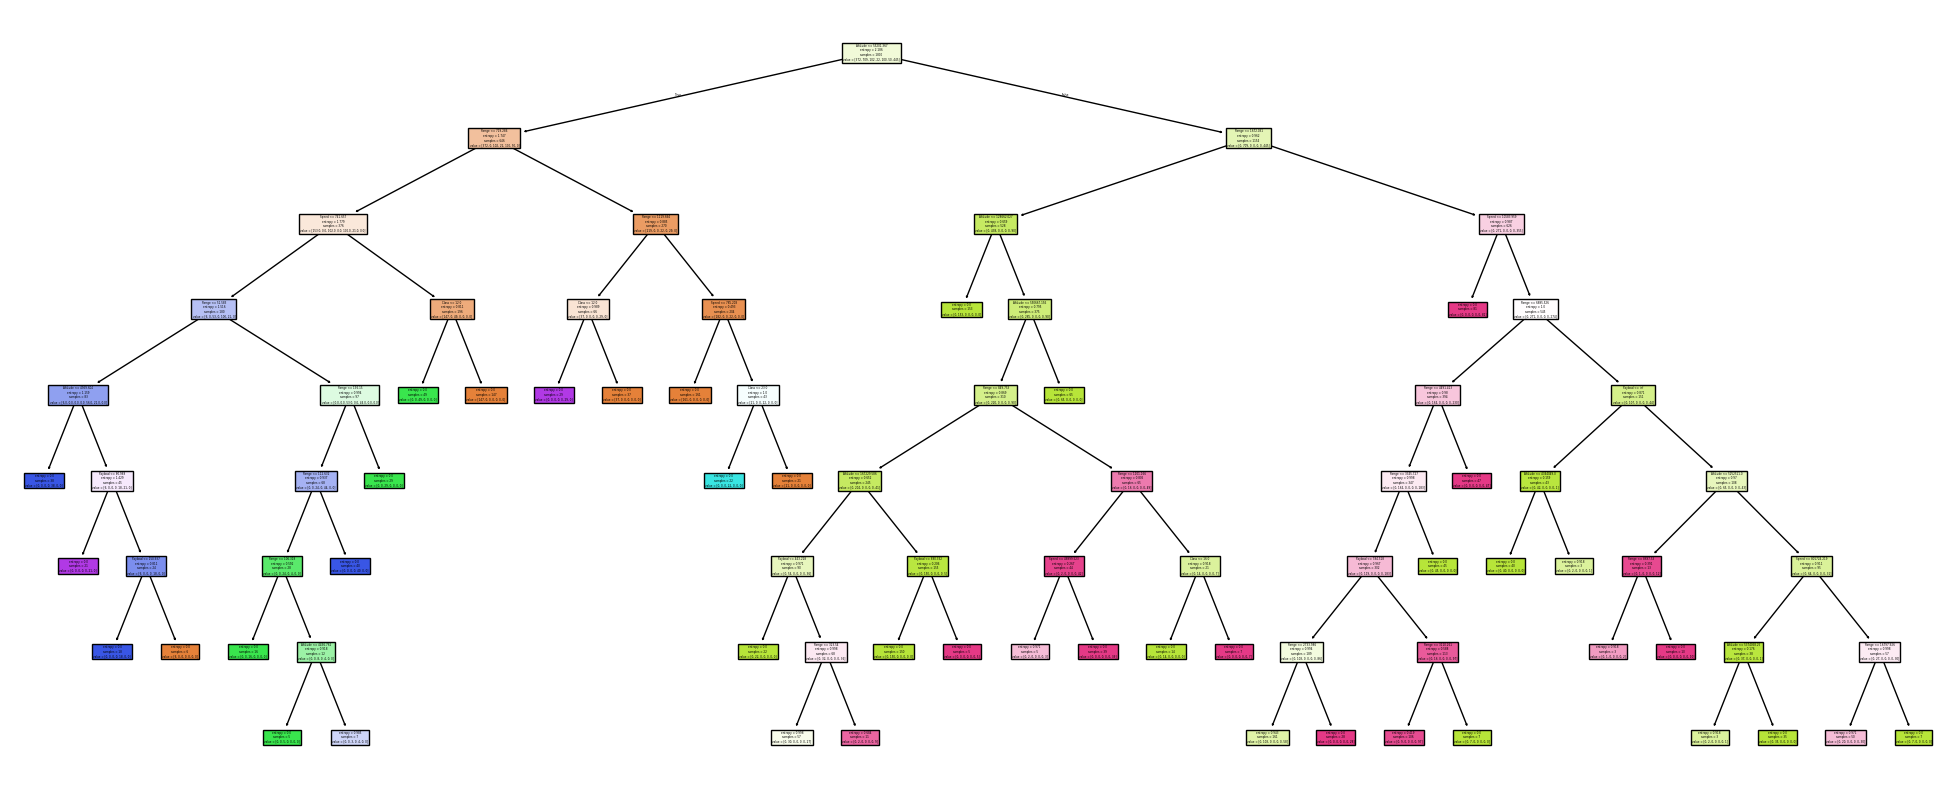

In [50]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25,10))

plot_tree(model,feature_names=X.columns,filled=True)

plt.show()

In [51]:
sample = [[2,12000,1700,120000,750]]

prediction = model.predict(sample)

interceptor = le_interceptor.inverse_transform(prediction)

print("Recommended Interceptor:",interceptor)

Recommended Interceptor: ['Arrow-3']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
